In [4]:
import pandas as pd

In [5]:
df=pd.read_csv('tweets.csv')
print(df.head())

                                                text  retweet_count  \
0  - Davvero ti piace quella figa di legno? - SÃ...            0.0   
1  Ognuno vale quanto ciÃÂ² che ricerca. Marco A...            0.0   
2  @Styla73 @stitchsarah glad for this update. If...            0.0   
3  I geni sono i piÃÂ¹ felici fra i mortali, per...            0.0   
4  Il nuovo profilo Twitter disponibile per tutti...            0.0   

   reply_count  favorite_count  num_hashtags  num_urls  num_mentions  target  
0          0.0             2.0           0.0       0.0           0.0       1  
1          0.0             1.0           0.0       0.0           0.0       1  
2          0.0             0.0           0.0       0.0           2.0       0  
3          0.0             0.0           0.0       0.0           0.0       1  
4          0.0             1.0           0.0       1.0           0.0       1  


In [6]:
df

,text,retweet_count,reply_count,favorite_count,num_hashtags,num_urls,num_mentions,target
0,- Davvero ti piace quella figa di legno? - SÃ...,0.0,0.0,2.0,0.0,0.0,0.0,1
1,Ognuno vale quanto ciÃÂ² che ricerca. Marco A...,0.0,0.0,1.0,0.0,0.0,0.0,1
2,@Styla73 @stitchsarah glad for this update. If...,0.0,0.0,0.0,0.0,0.0,2.0,0
3,"I geni sono i piÃÂ¹ felici fra i mortali, per...",0.0,0.0,0.0,0.0,0.0,0.0,1
4,Il nuovo profilo Twitter disponibile per tutti...,0.0,0.0,1.0,0.0,1.0,0.0,1
...,...,...,...,...,...,...,...,...
99995,RT @DanWarp: I'm having the BEST time working ...,6687.0,0.0,0.0,0.0,0.0,1.0,0
99996,Devo smetterla di guardare le Olimpiadi Invern...,0.0,0.0,0.0,0.0,0.0,0.0,1
99997,#Proverbi Chi ha il pane .......se lo magna #s...,0.0,0.0,0.0,2.0,0.0,0.0,1
99998,@fakerobhunter So how??,0.0,0.0,0.0,0.0,0.0,1.0,0


In [7]:
df.columns

Index(['text', 'retweet_count', 'reply_count', 'favorite_count',
       'num_hashtags', 'num_urls', 'num_mentions', 'target'],
      dtype='object')

In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (Input, Embedding, LSTM, Conv1D, 
                                     GlobalMaxPooling1D, Dense, Dropout, 
                                     Concatenate, BatchNormalization)
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [14]:
df['text'].iloc[0]

'- Davvero ti piace quella figa di legno? - SÃ\x83Â¬, ha il suo parquet.'

In [17]:
df.dropna(inplace=True)

In [ ]:

MAX_VOCAB_SIZE = 20000  # Maximum number of words to keep
MAX_SEQ_LEN = 100       # Max length of a tweet (padding/truncating)
EMBEDDING_DIM = 100     # Dimension of word vectors

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text'])
sequences = tokenizer.texts_to_sequences(df['text'])
X_text = pad_sequences(sequences, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')


In [9]:
# 3. Process Numerical Features
num_cols = ['retweet_count', 'reply_count', 'favorite_count', 
            'num_hashtags', 'num_urls', 'num_mentions']
X_num = df[num_cols].values

# Scale numerical data (Important for Neural Networks)
scaler = StandardScaler()
X_num = scaler.fit_transform(X_num)

# 4. Target
y = df['target'].values



NameError: name 'df' is not defined

In [104]:
df.columns

Index(['text', 'retweet_count', 'reply_count', 'favorite_count',
       'num_hashtags', 'num_urls', 'num_mentions', 'target'],
      dtype='object')

In [23]:
# 5. Split Data
# Note: We split text and numbers simultaneously
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_num, y, test_size=0.2, random_state=42
)

print(f"Train Size: {len(y_train)} samples")
print(f"Test Size: {len(y_test)} samples")

Train Size: 79829 samples
Test Size: 19958 samples


In [24]:


def build_lstm_cnn_model():
   
    
    text_input = Input(shape=(MAX_SEQ_LEN,), name='text_input')

    x = Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQ_LEN)(text_input)
     
    x = LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(x)
 
    x = Conv1D(filters=64, kernel_size=3, activation='relu')(x)
    
    # 4. Pooling
    x = GlobalMaxPooling1D()(x)
    
    # --- Branch 2: Numerical Processing ---
    num_input = Input(shape=(6,), name='num_input')
    y = Dense(32, activation='relu')(num_input)
    y = BatchNormalization()(y)
    
    # --- Fusion ---
    # Combine the "Understanding of Text" with "User Stats"
    combined = Concatenate()([x, y])
    
    z = Dense(64, activation='relu')(combined)
    z = Dropout(0.3)(z)
    
    # Output Layer (Binary Classification)
    output = Dense(1, activation='sigmoid')(z)
    
    model = Model(inputs=[text_input, num_input], outputs=output)
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_lstm_cnn_model()
model.summary()

c:\Users\taran\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 100)  │  2,000,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 100, 64)   │     42,240 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_input           │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 98, 64)    │     12,352 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        224 │ num_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32)        │        128 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      6,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,061,217 (7.86 MB)

 Trainable params: 2,061,153 (7.86 MB)

 Non-trainable params: 64 (256.00 B)

In [25]:
# [CELL 5]: Train Model

history = model.fit(
    x={'text_input': X_text_train, 'num_input': X_num_train},
    y=y_train,
    validation_data=(
        {'text_input': X_text_test, 'num_input': X_num_test},
        y_test
    ),
    epochs=5,
    batch_size=32
)   

Epoch 1/5
2495/2495 ━━━━━━━━━━━━━━━━━━━━ 178s 69ms/step - accuracy: 0.9813 - loss: 0.0643 - val_accuracy: 0.9902 - val_loss: 0.0418
Epoch 2/5
2495/2495 ━━━━━━━━━━━━━━━━━━━━ 240s 96ms/step - accuracy: 0.9900 - loss: 0.0390 - val_accuracy: 0.9904 - val_loss: 0.0503
Epoch 3/5
2495/2495 ━━━━━━━━━━━━━━━━━━━━ 257s 103ms/step - accuracy: 0.9916 - loss: 0.0315 - val_accuracy: 0.9903 - val_loss: 0.0450
Epoch 4/5
2495/2495 ━━━━━━━━━━━━━━━━━━━━ 244s 98ms/step - accuracy: 0.9929 - loss: 0.0250 - val_accuracy: 0.9904 - val_loss: 0.0531
Epoch 5/5
2495/2495 ━━━━━━━━━━━━━━━━━━━━ 174s 70ms/step - accuracy: 0.9937 - loss: 0.0207 - val_accuracy: 0.9879 - val_loss: 0.0642


624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.98      0.99      0.99      9976
        Fake       0.99      0.98      0.99      9982

    accuracy                           0.99     19958
   macro avg       0.99      0.99      0.99     19958
weighted avg       0.99      0.99      0.99     19958



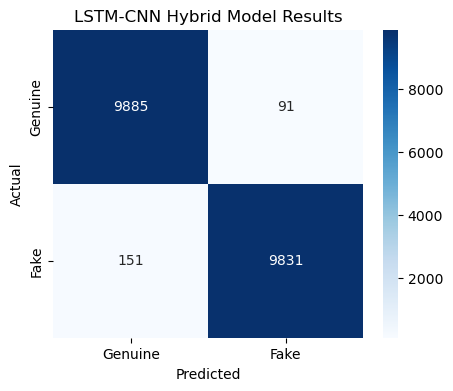

In [ ]:
 
y_pred_probs = model.predict({'text_input': X_text_test, 'num_input': X_num_test})
y_pred = (y_pred_probs > 0.5).astype(int)
 
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Genuine', 'Fake']))

 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Fake'], yticklabels=['Genuine', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LSTM-CNN Hybrid Model Results')
plt.show()

In [ ]:
import pickle

model.save('fake_account_model.h5')
print("Model saved as 'fake_account_model.h5'")

with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("Tokenizer saved as 'tokenizer.pickle'")

with open('scaler.pickle', 'wb') as handle:
    pickle.dump(scaler, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("Scaler saved as 'scaler.pickle'")

Model saved as 'fake_account_model.h5'
Tokenizer saved as 'tokenizer.pickle'
Scaler saved as 'scaler.pickle'


In [5]:
import tensorflow as tf

In [7]:
model = tf.keras.models.load_model('fake_account_model.h5')

In [8]:

raw_pred = model.predict({'text_input': X_text_test, 'num_input': X_num_test})

user_index = 60
bot_prob = raw_pred[user_index][0]   

bot_score = bot_prob * 100

confidence_score = abs(bot_prob - 0.5) * 2 * 100

print(f"--- Result for User #{user_index} ---")
print(f"Bot Score:        {bot_score:.2f}")       
print(f"Confidence Score: {confidence_score:.2f}") 

NameError: name 'X_text_test' is not defined

In [ ]:
max_len = MAX_SEQ_LEN


In [ ]:
def shap_predict_fn(X):
    X_text = X[:, :max_len].astype(int)
    X_num  = X[:, max_len:]
    return model.predict([X_text, X_num])


In [ ]:
import numpy as np

X_train_combined = np.hstack([X_text_train, X_num_train])
X_test_combined  = np.hstack([X_text_test,  X_num_test])


In [ ]:
import shap

background = X_train_combined[
    np.random.choice(X_train_combined.shape[0], 50, replace=False)
]

explainer = shap.KernelExplainer(shap_predict_fn, background)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step


In [ ]:
sample = X_test_combined[0:1]
shap_values = explainer.shap_values(sample)
shap_vals = shap_values[0]


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step


In [ ]:
np.save('shape_background.npy', background)

In [ ]:
index_word = {v: k for k, v in tokenizer.word_index.items()}

tokens = sample[0][:max_len]
text_shap_vals = shap_vals[:max_len]

text_explanation = [
    {
        "word": index_word.get(tok, "<PAD>"),
        "importance": float(val)
    }
    for tok, val in zip(tokens, text_shap_vals)
    if tok != 0
]


C:\Users\taran\AppData\Local\Temp\ipykernel_19576\1422621512.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "importance": float(val)


In [ ]:
num_feature_names = [
    "retweet_count",
    "reply_count",
    "favorite_count",
    "num_hashtags",
    "num_urls",
    "num_mentions"
]


In [ ]:
num_shap_vals = shap_vals[max_len:]

num_explanation = [
    {
        "feature": name,
        "importance": float(val)
    }
    for name, val in zip(num_feature_names, num_shap_vals)
]


C:\Users\taran\AppData\Local\Temp\ipykernel_19576\2638505901.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "importance": float(val)


In [ ]:
pred_prob = float(
    model.predict([
        sample[:, :max_len],
        sample[:, max_len:]
    ])[0][0]
)

final_response = {
    "prediction": "BOT" if pred_prob >= 0.5 else "HUMAN",
    "confidence": pred_prob,

    "text_explanation": {
        "top_bot_words": sorted(text_explanation, key=lambda x: x["importance"], reverse=True)[:5],
        "top_human_words": sorted(text_explanation, key=lambda x: x["importance"])[:5]
    },

    "numeric_explanation": {
        "top_bot_features": sorted(num_explanation, key=lambda x: x["importance"], reverse=True)[:5],
        "top_human_features": sorted(num_explanation, key=lambda x: x["importance"])[:5]
    }
}


NameError: name 'model' is not defined

In [ ]:
pred_prob


1.0

In [ ]:
final_response

{'prediction': 'BOT',
 'confidence': 1.0,
 'text_explanation': {'top_bot_words': [{'word': 'fai',
    'importance': 0.12939034083171735},
   {'word': 'bene', 'importance': 0.08349874668656126},
   {'word': 'che', 'importance': 0.07377295849745709},
   {'word': 'quello', 'importance': 0.06908852495123147},
   {'word': 'fare', 'importance': 0.06378839938587459}],
  'top_human_words': [{'word': 'berthold', 'importance': 0.0},
   {'word': 'brecht', 'importance': 0.0},
   {'word': 'devi', 'importance': 0.017891081797940522},
   {'word': 'va', 'importance': 0.02095406911644662},
   {'word': 'esitare', 'importance': 0.02567195444833327}]},
 'numeric_explanation': {'top_bot_features': [{'feature': 'retweet_count',
    'importance': 0.0},
   {'feature': 'reply_count', 'importance': 0.0},
   {'feature': 'favorite_count', 'importance': 0.0},
   {'feature': 'num_hashtags', 'importance': 0.0},
   {'feature': 'num_urls', 'importance': 0.0}],
  'top_human_features': [{'feature': 'retweet_count', 'imp